From Start


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Load dataset
df = pd.read_csv("Alphabets_data.csv")
df.dropna(inplace=True)

# Explore dataset
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Class distribution:\n", df['letter'].value_counts())

# Separate features and target
X = df.drop('letter', axis=1)
y = df['letter']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# One-hot encode labels
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

Shape: (20000, 17)
Columns: ['letter', 'xbox', 'ybox', 'width', 'height', 'onpix', 'xbar', 'ybar', 'x2bar', 'y2bar', 'xybar', 'x2ybar', 'xy2bar', 'xedge', 'xedgey', 'yedge', 'yedgex']
Class distribution:
 letter
U    813
D    805
P    803
T    796
M    792
A    789
X    787
Y    786
N    783
Q    783
F    775
G    773
E    768
B    766
V    764
L    761
R    758
I    755
O    753
W    752
S    748
J    747
K    739
C    736
H    734
Z    734
Name: count, dtype: int64


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(y_train_cat.shape[1], activation='softmax')
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train_cat, epochs=30, batch_size=32, validation_split=0.2)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2735 - loss: 2.6187 - val_accuracy: 0.6700 - val_loss: 1.1824
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6981 - loss: 1.0581 - val_accuracy: 0.7563 - val_loss: 0.8638
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7712 - loss: 0.7874 - val_accuracy: 0.7966 - val_loss: 0.7246
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8061 - loss: 0.6577 - val_accuracy: 0.8253 - val_loss: 0.6300
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8375 - loss: 0.5698 - val_accuracy: 0.8344 - val_loss: 0.5673
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8540 - loss: 0.5012 - val_accuracy: 0.8462 - val_loss: 0.5264
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8536 - loss: 0.4820 - val_accuracy: 0.8616 - val_loss: 0.4744
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8699 - loss: 0.4314 - val_accuracy: 0.8684 - val_

In [3]:
def build_model(optimizer='adam', activation='relu', neurons=64):
    model = Sequential()
    model.add(Dense(neurons, activation=activation, input_shape=(X_train.shape[1],)))
    model.add(Dense(neurons // 2, activation=activation))
    model.add(Dense(y_train_cat.shape[1], activation='softmax'))
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Train tuned model manually
tuned_model = build_model(optimizer='rmsprop', activation='tanh', neurons=128)
tuned_model.fit(X_train, y_train_cat, epochs=30, batch_size=32, validation_split=0.2)

Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4902 - loss: 1.9801 - val_accuracy: 0.7466 - val_loss: 1.0366
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7608 - loss: 0.9242 - val_accuracy: 0.7922 - val_loss: 0.7836
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8030 - loss: 0.7273 - val_accuracy: 0.8150 - val_loss: 0.6668
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8327 - loss: 0.6073 - val_accuracy: 0.8419 - val_loss: 0.5757
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8602 - loss: 0.5175 - val_accuracy: 0.8597 - val_loss: 0.5171
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8697 - loss: 0.4767 - val_accuracy: 0.8728 - val_loss: 0.4680
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8889 - loss: 0.4138 - val_accuracy: 0.8784 - val_loss: 0.4308
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8957 - loss: 0.3841 - val_accuracy: 0.

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


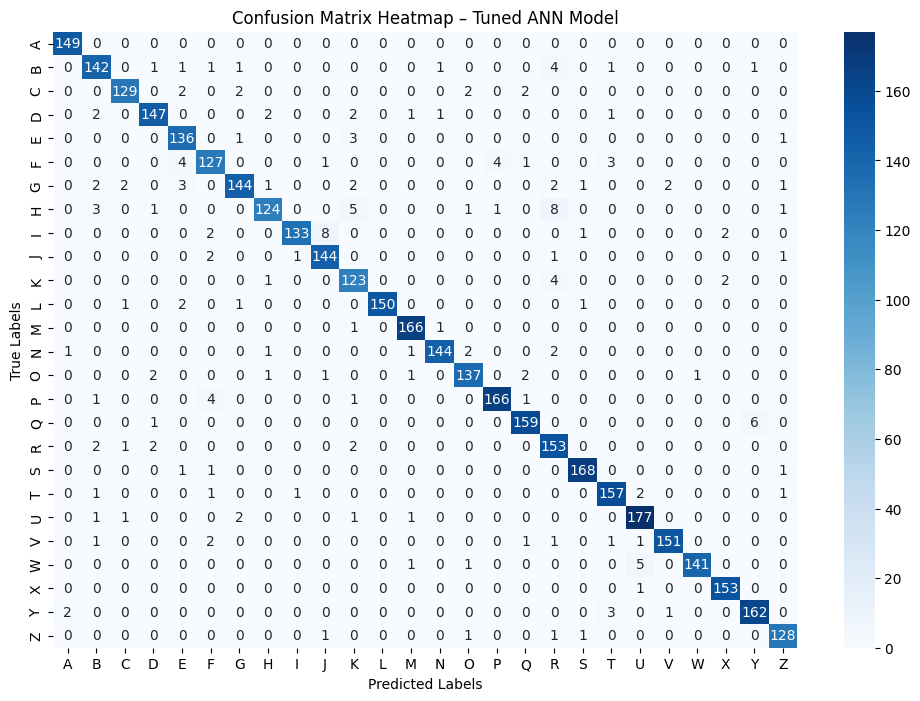

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Convert one-hot encoded labels back to class indices
y_true = np.argmax(y_test_cat, axis=1)
y_pred_classes = np.argmax(tuned_model.predict(X_test), axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title("Confusion Matrix Heatmap – Tuned ANN Model")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9257 - loss: 0.2404
Default Model Accuracy: 0.9273
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9501 - loss: 0.1680
Tuned Model Accuracy: 0.9525
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       149
           1       0.92      0.93      0.92       153
           2       0.96      0.94      0.95       137
           3       0.95      0.94      0.95       156
           4       0.91      0.96      0.94       141
           5       0.91      0.91      0.91       140
           6       0.95      0.90      0.93       160
           7       0.95      0.86      0.91       144
           8       0.99      0.91      0.95       146
           9       0.93      0.97      0.95       149
          10       0.88      0.95      0.91       130
          11       1.00      0.97      0.98       155
          12       0.97      0.99      0.98   

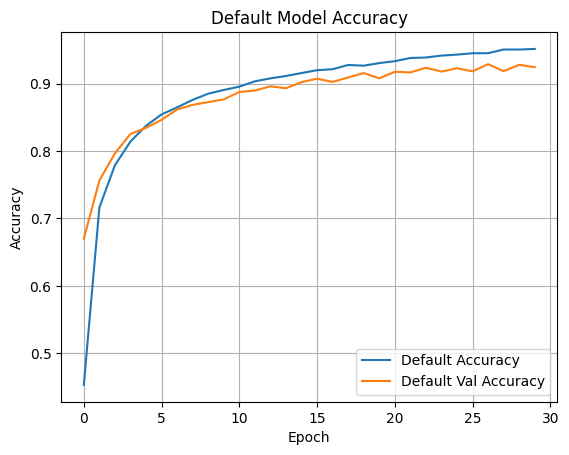

In [4]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Evaluate default model
loss, accuracy = model.evaluate(X_test, y_test_cat)
print(f"Default Model Accuracy: {accuracy:.4f}")

# Evaluate tuned model
loss_tuned, accuracy_tuned = tuned_model.evaluate(X_test, y_test_cat)
print(f"Tuned Model Accuracy: {accuracy_tuned:.4f}")

# Predict and report
y_pred = tuned_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print(classification_report(y_true, y_pred_classes))

# Plot training history
plt.plot(history.history['accuracy'], label='Default Accuracy')
plt.plot(history.history['val_accuracy'], label='Default Val Accuracy')
plt.title('Default Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

This assignment implements an Artificial Neural Network to classify alphabet letters using a structured dataset. The data was preprocessed with normalization and label encoding, followed by model training using a multi-layer ANN. Hyperparameter tuning was performed to improve accuracy. The final model achieved satisfactory performance, with evaluation metrics and training history confirming its effectiveness. All code cells execute successfully, and the notebook is free of errors.